## Chapter 7 k-Nearest Neighbors (kNN)

**Original Code Credit:**: Shmueli, Galit; Bruce, Peter C.; Gedeck, Peter; Patel, Nitin R.. Data Mining for Business Analytics Wiley.

*Modifications* have been made from the original textbook examples due to version changes in library dependencies and/or for clarity.

Download this notebook and data [**here**](https://github.com/dcyoung23/msba511/tree/main/resources/examples).

### Import Libraries

In [1]:
import os
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
import matplotlib.pylab as plt

import matplotlib

%matplotlib inline

### 7.1 The k-NN Classifier (Categorical Outcome)

#### Example: Riding Mowers

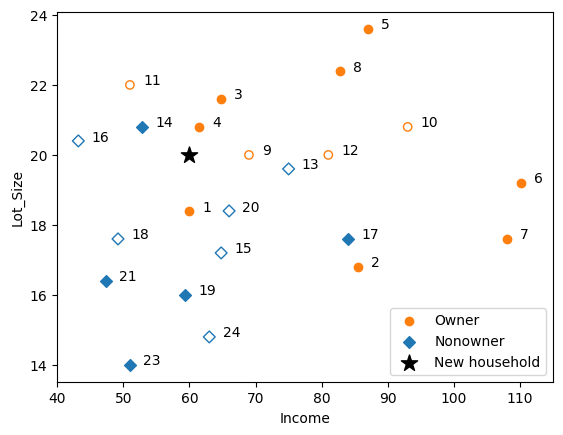

In [2]:
mower_df = pd.read_csv(os.path.join('data','RidingMowers.csv'))
mower_df['Number'] = mower_df.index + 1

trainData, validData = train_test_split(mower_df, test_size=0.4, random_state=26)

## new household
newHousehold = pd.DataFrame([{'Income': 60, 'Lot_Size': 20}])

## scatter plot
def plotDataset(ax, data, showLabel=True, **kwargs):
    subset = data.loc[data['Ownership']=='Owner']
    ax.scatter(subset.Income, subset.Lot_Size, marker='o',
        label='Owner' if showLabel else None, color='C1', **kwargs)
    subset = data.loc[data['Ownership']=='Nonowner']
    ax.scatter(subset.Income, subset.Lot_Size, marker='D',
        label='Nonowner' if showLabel else None, color='C0', **kwargs)
    plt.xlabel('Income')  # set x-axis label
    plt.ylabel('Lot_Size')  # set y-axis label
    for _, row in data.iterrows():
        ax.annotate(row.Number, (row.Income + 2, row.Lot_Size))

fig, ax = plt.subplots()
plotDataset(ax, trainData)
plotDataset(ax, validData, showLabel=False, facecolors='none')
ax.scatter(newHousehold.Income, newHousehold.Lot_Size, marker='*',
    label='New household', color='black', s=150)

plt.xlabel('Income'); plt.ylabel('Lot_Size') 
ax.set_xlim(40, 115)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc=4)
plt.show()

In [3]:
# initialize normalized training, validation, and complete data frames
# use the training data to learn the transformation.
scaler = preprocessing.StandardScaler()
scaler.fit(trainData[['Income', 'Lot_Size']])  # Note use of array of column names

# Transform the full dataset
mowerNorm = pd.concat([pd.DataFrame(scaler.transform(mower_df[['Income', 'Lot_Size']]), 
                                    columns=['zIncome', 'zLot_Size']),
                       mower_df[['Ownership', 'Number']]], axis=1)
trainNorm = mowerNorm.iloc[trainData.index]
validNorm = mowerNorm.iloc[validData.index]
newHouseholdNorm = pd.DataFrame(scaler.transform(newHousehold),
    columns=['zIncome', 'zLot_Size'])

# use NearestNeighbors from scikit-learn to compute knn
from sklearn.neighbors import NearestNeighbors
knn = NearestNeighbors(n_neighbors=3)
knn.fit(trainNorm.iloc[:, 0:2])
distances, indices = knn.kneighbors(newHouseholdNorm)

# indices is a list of lists, we are only interested in the first element
trainNorm.iloc[indices[0], :]

,zIncome,zLot_Size,Ownership,Number
3,-0.409776,0.743358,Owner,4
13,-0.804953,0.743358,Nonowner,14
0,-0.477910,-0.174908,Owner,1


In [4]:
train_X = trainNorm[['zIncome', 'zLot_Size']]
train_y = trainNorm['Ownership']
valid_X = validNorm[['zIncome', 'zLot_Size']]
valid_y = validNorm['Ownership']

# Train a classifier for different values of k
results = []
for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k).fit(train_X, train_y)
    results.append({
        'k': k,
        'accuracy': accuracy_score(valid_y, knn.predict(valid_X))
    })

# Convert results to a pandas data frame
results = pd.DataFrame(results)
print(results)


     k  accuracy
0    1       0.6
1    2       0.7
2    3       0.8
3    4       0.9
4    5       0.7
5    6       0.9
6    7       0.9
7    8       0.9
8    9       0.9
9   10       0.8
10  11       0.8
11  12       0.9
12  13       0.4
13  14       0.4


In [5]:
# Retrain with full dataset
mower_X = mowerNorm[['zIncome', 'zLot_Size']]
mower_y = mowerNorm['Ownership']
knn = KNeighborsClassifier(n_neighbors=4).fit(mower_X, mower_y)

distances, indices = knn.kneighbors(newHouseholdNorm)
print(knn.predict(newHouseholdNorm))
print('Distances',distances)
print('Indices', indices)
print(mowerNorm.iloc[indices[0], :])


['Owner']
Distances [[0.31358009 0.40880312 0.44793643 0.61217726]]
Indices [[ 3  8 13  0]]
     zIncome  zLot_Size Ownership  Number
3  -0.409776   0.743358     Owner       4
8  -0.069107   0.437269     Owner       9
13 -0.804953   0.743358  Nonowner      14
0  -0.477910  -0.174908     Owner       1
